# 3.1 Basic — Lag-Only Models

Lag features only (polymarket lags that survived feature selection).

**Pipeline:** Gold → Model outputs  
**Input:** `Data/3_Gold/basetable_preprocessed.csv`  
**Output:** Model metrics and visualisations

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Load Data & Compute Target](#1-load-data-compute-target)
- [2. Train/Val/Test Split](#2-trainvaltest-split)
- [3. CV Folds](#3-cv-folds)
- [4. Helper Functions](#4-helper-functions)
- [5. Model 1 — Ridge Regression](#5-model-1-ridge-regression)
- [6. Model 2 — Random Forest Regressor](#6-model-2-random-forest-regressor)
- [7. Model 3 — Support Vector Regression (tuned kernel)](#7-model-3-support-vector-regression-tuned-kernel)
- [8. Model 4 — XGBoost Regressor](#8-model-4-xgboost-regressor)
- [9. Naive Baseline — Always Predict Zero](#9-naive-baseline-always-predict-zero)
- [10. Model Comparison](#10-model-comparison)


## Setup

In [23]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iterproduct

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("XGBoost not found. Install with: pip install xgboost")

from Functions.data_splits import (
    get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage,
)
from house_style import *
apply_style()

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

DATA_PATH = "../../../Data/3_Gold/basetable_preprocessed.csv"

MODEL_COLORS = {
    "Naive (zero)"     : NEUTRAL,
    "Ridge Regression" : PALETTE[0],
    "Random Forest"    : PALETTE[1],
    "SVM"              : PALETTE[4],
    "XGBoost"          : PALETTE[2],
}

print("Imports OK")

Imports OK


## 1. Load Data & Compute Target

We load `basetable_preprocessed.csv` — the cleaned, leakage-free output of `preprocessing.ipynb` — and use only the two polymarket lag columns that survived feature selection.

**Why only lag1 and lag4?**  
Feature selection in preprocessing dropped lag2, lag3, and lag5 because their pairwise Spearman correlation with lag1 exceeded 0.90 — they are near-redundant. We respect that decision and use the pipeline's output as-is.

**Target derivation:**  
`price_change` was removed as a *feature* in preprocessing because it leaks today's target. As the *target* itself it is perfectly valid:
```
target(t) = polymarket_trump_prob(t) − polymarket_trump_prob_lag1(t)
           = prob(t) − prob(t−1)
```

In [24]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

# Only the two lag columns that survived preprocessing feature selection
LAG_COLS = [
    "polymarket_trump_prob_lag1",
    "polymarket_trump_prob_lag4",
]

missing = [c for c in LAG_COLS if c not in df_raw.columns]
assert not missing, f"Missing columns: {missing} — re-run preprocessing.ipynb"

df = df_raw[["date"] + LAG_COLS].copy()
df["target"] = df_raw["polymarket_trump_prob"] - df_raw["polymarket_trump_prob_lag1"]

assert df.isna().sum().sum() == 0, "NaN detected — check basetable_preprocessed.csv"

print(f"Rows          : {len(df)}")
print(f"Date range    : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Features ({len(LAG_COLS)}): {LAG_COLS}")
print(f"\nTarget (daily delta prob) stats:")
print(df["target"].describe().round(5))

Rows          : 123
Date range    : 2024-07-05 -> 2024-11-04
Features (2): ['polymarket_trump_prob_lag1', 'polymarket_trump_prob_lag4']

Target (daily delta prob) stats:
count    123.00000
mean      -0.00020
std        0.01782
min       -0.06000
25%       -0.01000
50%        0.00000
75%        0.00900
max        0.08000
Name: target, dtype: float64


## 2. Train/Val/Test Split

`get_test_split` carves off the **last 14 rows** (Oct 22 – Nov 4) as a completely held-out test set. These dates are never seen during training or model selection — they are used only once for the final reported numbers.

The remaining 109 rows form the **TV (train/validation) set**, split further into CV folds.

In [25]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[LAG_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[LAG_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} -> {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} -> {df_test['date'].max().date()})")

Train/val :  109 rows  (2024-07-05 -> 2024-10-21)
Test      :   14 rows  (2024-10-22 -> 2024-11-04)


## 3. CV Folds

We build **3 expanding-window folds** on the TV set with a 1-day gap between each train and validation window. The gap prevents rolling-feature bleed: if the last training day and the first validation day were adjacent, a rolling-average feature on day t could still include training rows.

Folds are built on `df_tv` with `test_days=None` — the test set has already been separated above, so we pass only the TV portion here.

`validate_no_leakage` asserts three things per fold:
1. No row index appears in both train and val
2. All training dates are strictly earlier than all validation dates
3. The calendar gap between the last training date and the first validation date is at least `GAP` days

In [26]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 4. Helper Functions

**`directional_accuracy`** — fraction of predictions where the predicted sign matches the actual sign. A value of 0.5 means the model is no better than a coin flip for calling the direction of the next move.

**`compute_metrics`** — returns MAE, RMSE, Directional Accuracy, R² as a dict.

**`tune_hyperparams`** — grid search using the walk-forward CV folds:
- Iterates over all hyperparameter combinations in `param_grid`
- For each combination: runs every CV fold, fits a scaler on the train fold only (if `scale=True`), records fold MAEs
- Returns the best parameter dict (minimum mean CV MAE) and a sorted results DataFrame
- **Note:** since tuning and evaluation use the same folds, CV metrics after tuning are slightly optimistic. With only ~27–81 training rows, nested CV would produce unstable inner estimates, so this trade-off is accepted.

**`cv_evaluate`** — walk-forward CV loop with a given model factory; reports per-fold and mean metrics.

**`final_eval`** — retrains on all TV data with given factory, evaluates once on the held-out test set.

In [27]:
from functions.evaluation_metrics import (
    directional_accuracy, compute_metrics, cv_evaluate, final_eval, tune_hyperparams
)

## 5. Model 1 — Ridge Regression

Ridge Regression adds an L2 penalty to OLS: `β̂ = argmin ||y − Xβ||² + α||β||²`. The penalty shrinks coefficients toward zero, reducing variance at the cost of a small bias — beneficial when features are correlated (lag1 and lag4 have |ρ| ≈ 0.84).

**Tuned hyperparameter:** `alpha` — the L2 penalty strength; tuned over a log-scale grid via walk-forward CV.

**Scaling applied** — required so the penalty is applied equally across features regardless of scale.

In [28]:
def make_ridge(alpha):
    return Ridge(alpha=alpha)

ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}

print("=== Ridge Regression — Hyperparameter Tuning ===")
ridge_best, ridge_tune_df = tune_hyperparams(
    make_ridge, ridge_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {ridge_best}")
print(f"\n  All configurations (sorted by CV MAE):")
print(ridge_tune_df.to_string(index=False))

lr_factory = lambda: make_ridge(**ridge_best)
print("\n=== Ridge Regression — CV (best params) ===")
lr_cv = cv_evaluate(lr_factory, folds, X_tv, y_tv, scale=True)
lr_cv.round(4)

=== Ridge Regression — Hyperparameter Tuning ===
  Best params : {'alpha': 100.0}

  All configurations (sorted by CV MAE):
   alpha   cv_mae  cv_mae_std
 100.000 0.010236    0.001873
 500.000 0.010263    0.001836
1000.000 0.010280    0.001826
  10.000 0.010822    0.002446
   1.000 0.011174    0.002793
   0.100 0.011230    0.002848
   0.010 0.011236    0.002854
   0.001 0.011237    0.002855

=== Ridge Regression — CV (best params) ===
  Fold 1: MAE=0.0115  RMSE=0.0149  DA=0.593  R2=0.0153
  Fold 2: MAE=0.0076  RMSE=0.0098  DA=0.481  R2=0.0088
  Fold 3: MAE=0.0117  RMSE=0.0162  DA=0.333  R2=-0.2818
  -- Mean --  MAE=0.0102  RMSE=0.0136  DA=0.469  R2=-0.0859


,MAE,RMSE,Dir. Accuracy,R2
1,0.0115,0.0149,0.5926,0.0153
2,0.0076,0.0098,0.4815,0.0088
3,0.0117,0.0162,0.3333,-0.2818
Mean,0.0102,0.0136,0.4691,-0.0859
Std,0.0023,0.0034,0.1301,0.1697


In [29]:
lr_model, lr_pred, lr_test = final_eval(
    lr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("Ridge Regression — Test set:")
for k, v in lr_test.items():
    print(f"  {k}: {v:.4f}")

sc_r = StandardScaler().fit(X_tv)
ridge_coef_model = make_ridge(**ridge_best)
ridge_coef_model.fit(sc_r.transform(X_tv), y_tv)
coefs = pd.Series(ridge_coef_model.coef_, index=LAG_COLS)
print(f"\nFitted coefficients (standardised features, alpha={ridge_best['alpha']}):")
print(coefs.round(5).to_string())

Ridge Regression — Test set:
  MAE: 0.0161
  RMSE: 0.0204
  Dir. Accuracy: 0.5000
  R2: -0.0215

Fitted coefficients (standardised features, alpha=100.0):
polymarket_trump_prob_lag1   -0.00088
polymarket_trump_prob_lag4   -0.00017


## 6. Model 2 — Random Forest Regressor

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample with a random feature subset at each split. Predictions are averaged across trees, reducing variance compared to a single tree.

**Why RF with only 5 features?** Even a small feature set can exhibit interactions (e.g., a large lag1 combined with a specific lag4 pattern) that linear models miss. RF captures these non-linearities without explicit feature engineering.

**Fixed hyperparameters:** `n_estimators=200` (sufficient ensemble size), `random_state=42`.

**Tuned hyperparameters:**
- `max_depth` — maximum tree depth; shallow trees prevent overfitting on small training folds
- `min_samples_leaf` — minimum observations per leaf; higher values smooth predictions

**No scaling required** — decision-tree splits are threshold-based, scale-invariant.

In [30]:
def make_rf(max_depth, min_samples_leaf):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

# ── Tuning ────────────────────────────────────────────────────────────────────
rf_param_grid = {
    "max_depth"       : [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3, 5],
}

print("=== Random Forest — Hyperparameter Tuning ===")
rf_best, rf_tune_df = tune_hyperparams(
    make_rf, rf_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {rf_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(rf_tune_df.head(5).to_string(index=False))

# ── CV evaluation with best params ────────────────────────────────────────────
rf_factory = lambda: make_rf(**rf_best)
print("\n=== Random Forest — CV (best params) ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'min_samples_leaf': 5}

  Top-5 configurations (sorted by CV MAE):
 max_depth  min_samples_leaf   cv_mae  cv_mae_std
         2                 5 0.010658    0.002192
         2                 3 0.011124    0.002632
         3                 5 0.011168    0.002653
         4                 5 0.011326    0.002734
         5                 5 0.011328    0.002754

=== Random Forest — CV (best params) ===
  Fold 1: MAE=0.0124  RMSE=0.0157  DA=0.444  R2=-0.0858
  Fold 2: MAE=0.0076  RMSE=0.0098  DA=0.407  R2=0.0035
  Fold 3: MAE=0.0121  RMSE=0.0165  DA=0.444  R2=-0.3387
  -- Mean --  MAE=0.0107  RMSE=0.0140  DA=0.432  R2=-0.1403


,MAE,RMSE,Dir. Accuracy,R2
1,0.0124,0.0157,0.4444,-0.0858
2,0.0076,0.0098,0.4074,0.0035
3,0.0121,0.0165,0.4444,-0.3387
Mean,0.0107,0.0140,0.4321,-0.1403
Std,0.0027,0.0036,0.0214,0.1775


Random Forest — Test set:
  MAE: 0.0170
  RMSE: 0.0201
  Dir. Accuracy: 0.5714
  R2: 0.0073


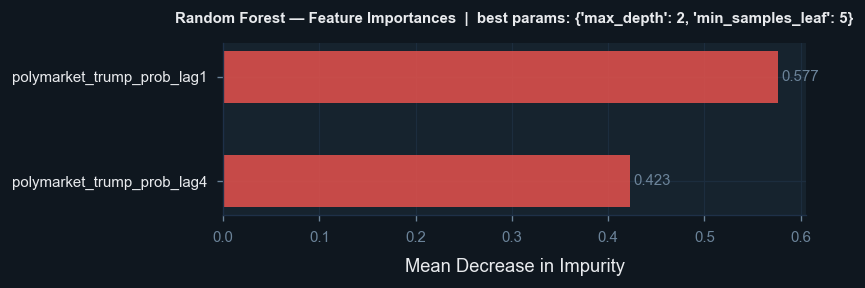

In [31]:
rf_model, rf_pred, rf_test = final_eval(
    rf_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("Random Forest — Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

fi = pd.Series(rf_model.feature_importances_, index=LAG_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 2.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(fi.index, fi.values, color=MODEL_COLORS["Random Forest"], alpha=0.85, height=0.5)
for bar, v in zip(bars, fi.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("Mean Decrease in Impurity", color=TEXT_PRIMARY)
ax.set_title(f"Random Forest — Feature Importances  |  best params: {rf_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(fi.index, color=TEXT_PRIMARY)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. Model 3 — Support Vector Regression (tuned kernel)

SVR finds a regression function that keeps predictions within an epsilon-tube around the true values while maximising the margin. The **kernel** implicitly maps features into a higher-dimensional space, enabling non-linear regression.

**Available kernels:**
- `linear` — standard linear regression within SVR's margin framework (no kernel trick)
- `rbf` — Radial Basis Function; infinite-dimensional mapping; most commonly used
- `poly` — polynomial kernel (degree = 3); captures polynomial interactions
- `sigmoid` — tanh kernel; neural-network-like behaviour

**Fixed hyperparameter:** `gamma='scale'` — sets gamma = 1 / (n_features × Var(X)); valid and appropriate for all kernels (ignored for `linear`).

**Tuned hyperparameters:**
- `kernel` — which kernel function to use; selected by CV
- `C` — regularisation strength; higher C = tighter fit, less regularisation
- `epsilon` — tube half-width; predictions within ε of truth incur zero loss; kept small given daily changes have std ≈ 0.018

**Scaling required** — SVR maximises a geometric margin; unscaled features distort distances in feature space.

In [32]:
def make_svr(kernel, C, epsilon):
    return SVR(kernel=kernel, C=C, epsilon=epsilon, gamma="scale")

# ── Tuning ────────────────────────────────────────────────────────────────────
# 4 kernels × 4 C values × 4 epsilon values = 64 combinations
svr_param_grid = {
    "kernel" : ["linear", "rbf", "poly", "sigmoid"],
    "C"      : [0.1, 1.0, 10.0, 100.0],
    "epsilon": [0.0001, 0.001, 0.01, 0.05],
}

print("=== SVM — Hyperparameter Tuning ===")
svr_best, svr_tune_df = tune_hyperparams(
    make_svr, svr_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {svr_best}")
print(f"\n  Top-10 configurations (sorted by CV MAE):")
print(svr_tune_df.head(10).to_string(index=False))

# ── CV evaluation with best params ────────────────────────────────────────────
svr_factory = lambda: make_svr(**svr_best)
print("\n=== SVM — CV (best params) ===")
svm_cv = cv_evaluate(svr_factory, folds, X_tv, y_tv, scale=True)
svm_cv.round(4)

=== SVM — Hyperparameter Tuning ===
  Best params : {'kernel': 'linear', 'C': 100.0, 'epsilon': 0.0001}

  Top-10 configurations (sorted by CV MAE):
kernel     C  epsilon   cv_mae  cv_mae_std
linear 100.0   0.0001 0.010456    0.002224
linear   1.0   0.0001 0.010463    0.002226
linear  10.0   0.0001 0.010479    0.002251
linear   0.1   0.0001 0.010483    0.002248
linear 100.0   0.0010 0.010696    0.002327
linear   0.1   0.0010 0.010714    0.002337
linear   1.0   0.0010 0.010780    0.002390
linear  10.0   0.0010 0.010842    0.002390
   rbf   0.1   0.0500 0.011579    0.002212
   rbf  10.0   0.0500 0.011711    0.002079

=== SVM — CV (best params) ===
  Fold 1: MAE=0.0115  RMSE=0.0151  DA=0.519  R2=-0.0029
  Fold 2: MAE=0.0074  RMSE=0.0095  DA=0.519  R2=0.0778
  Fold 3: MAE=0.0125  RMSE=0.0173  DA=0.370  R2=-0.4640
  -- Mean --  MAE=0.0105  RMSE=0.0139  DA=0.469  R2=-0.1297


,MAE,RMSE,Dir. Accuracy,R2
1,0.0115,0.0151,0.5185,-0.0029
2,0.0074,0.0095,0.5185,0.0778
3,0.0125,0.0173,0.3704,-0.4640
Mean,0.0105,0.0139,0.4691,-0.1297
Std,0.0027,0.0040,0.0855,0.2923


In [33]:
svm_model, svm_pred, svm_test = final_eval(
    svr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print(f"SVM — Test set  (kernel={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}):")
for k, v in svm_test.items():
    print(f"  {k}: {v:.4f}")

SVM — Test set  (kernel=linear, C=100.0, ε=0.0001):
  MAE: 0.0163
  RMSE: 0.0200
  Dir. Accuracy: 0.5714
  R2: 0.0245


## 8. Model 4 — XGBoost Regressor

XGBoost builds an additive ensemble of shallow regression trees sequentially: each new tree fits the pseudo-residuals (negative gradient of the loss) of the current ensemble. This boosting approach typically outperforms bagging (Random Forest) when individual trees are kept very shallow and many are combined.

**Fixed hyperparameters:** `subsample=0.8`, `colsample_bytree=0.8` (stochastic boosting for regularisation), `objective='reg:squarederror'`, `random_state=42`.

**Tuned hyperparameters:**
- `max_depth` — depth of each tree; boosting benefits from very shallow trees (depth 2–4)
- `learning_rate` — shrinkage applied to each tree's contribution; lower = more robust but needs more trees
- `n_estimators` — number of boosting rounds; jointly tuned with learning_rate

**No scaling required** — tree-based splits are threshold-based, scale-invariant.

In [34]:
def make_xgb(max_depth, learning_rate, n_estimators):
    return XGBRegressor(
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
    )

# ── Tuning ────────────────────────────────────────────────────────────────────
xgb_param_grid = {
    "max_depth"    : [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators" : [100, 200],
}

print("=== XGBoost — Hyperparameter Tuning ===")
xgb_best, xgb_tune_df = tune_hyperparams(
    make_xgb, xgb_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {xgb_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(xgb_tune_df.head(5).to_string(index=False))

# ── CV evaluation with best params ────────────────────────────────────────────
xgb_factory = lambda: make_xgb(**xgb_best)
print("\n=== XGBoost — CV (best params) ===")
xgb_cv = cv_evaluate(xgb_factory, folds, X_tv, y_tv, scale=False)
xgb_cv.round(4)

=== XGBoost — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'learning_rate': 0.01, 'n_estimators': 100}

  Top-5 configurations (sorted by CV MAE):
 max_depth  learning_rate  n_estimators   cv_mae  cv_mae_std
         2           0.01           100 0.011077    0.002659
         3           0.01           100 0.011126    0.002910
         4           0.01           100 0.011248    0.002972
         2           0.01           200 0.011862    0.003620
         3           0.01           200 0.012164    0.004022

=== XGBoost — CV (best params) ===
  Fold 1: MAE=0.0141  RMSE=0.0171  DA=0.556  R2=-0.2968
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.519  R2=-0.0034
  Fold 3: MAE=0.0115  RMSE=0.0159  DA=0.444  R2=-0.2388
  -- Mean --  MAE=0.0111  RMSE=0.0143  DA=0.506  R2=-0.1797


,MAE,RMSE,Dir. Accuracy,R2
1,0.0141,0.0171,0.5556,-0.2968
2,0.0076,0.0099,0.5185,-0.0034
3,0.0115,0.0159,0.4444,-0.2388
Mean,0.0111,0.0143,0.5062,-0.1797
Std,0.0033,0.0039,0.0566,0.1554


XGBoost — Test set:
  MAE: 0.0162
  RMSE: 0.0200
  Dir. Accuracy: 0.5714
  R2: 0.0165


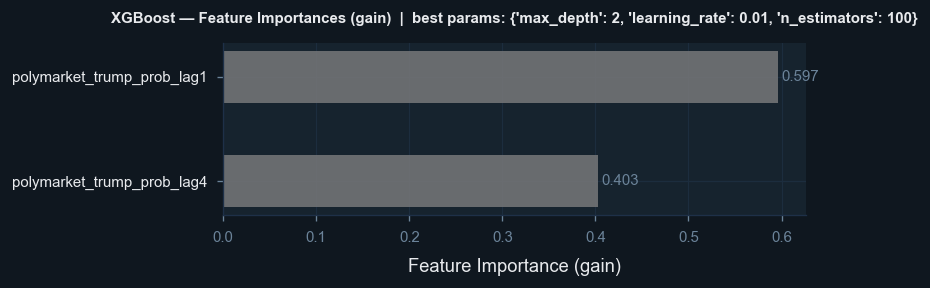

In [35]:
xgb_model, xgb_pred, xgb_test = final_eval(
    xgb_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("XGBoost — Test set:")
for k, v in xgb_test.items():
    print(f"  {k}: {v:.4f}")

# Gain-based feature importance: average improvement in squared-error loss
# brought by splitting on each feature across all boosting rounds
fi_xgb = pd.Series(xgb_model.feature_importances_, index=LAG_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 2.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(fi_xgb.index, fi_xgb.values, color=MODEL_COLORS["XGBoost"], alpha=0.85, height=0.5)
for bar, v in zip(bars, fi_xgb.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("Feature Importance (gain)", color=TEXT_PRIMARY)
ax.set_title(f"XGBoost — Feature Importances (gain)  |  best params: {xgb_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(fi_xgb.index, color=TEXT_PRIMARY)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 9. Naive Baseline — Always Predict Zero

The naive model always predicts `Δ prob = 0`, i.e., "no change tomorrow." This implements the **random walk hypothesis**: the best forecast of tomorrow's price is today's price.

This is the correct lower-bound baseline for this target because:
- If the daily change series is a random walk, zero is the optimal predictor in expectation
- R² ≈ 0 for the zero predictor when the mean daily change is near zero — which is exactly the R² = 0 reference line on the bar chart
- Any model with R² < 0 or MAE higher than the naive model is strictly worse than doing nothing

**Note on Directional Accuracy:** `sign(0) = 0` in NumPy, so our DA metric counts a correct prediction only on days where the actual change is also exactly zero. For a series with continuous values this will be near 0 — which is a useful lower bound showing how much harder it is to get the direction right than to just predict no movement.

In [36]:
# ── CV metrics for the zero predictor ────────────────────────────────────────
print("=== Naive (zero) — CV ===")
naive_records = []
for i, (train_idx, val_idx) in enumerate(folds, 1):
    y_val  = y_tv[val_idx]
    y_zero = np.zeros_like(y_val)
    m = {"Fold": i, **compute_metrics(y_val, y_zero)}
    naive_records.append(m)
    print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")

naive_agg  = pd.DataFrame(naive_records).set_index("Fold")
naive_mean = naive_agg.mean().rename("Mean")
naive_std  = naive_agg.std().rename("Std")
naive_cv   = pd.concat([naive_agg, naive_mean.to_frame().T, naive_std.to_frame().T])
print(f"  -- Mean --  MAE={naive_mean['MAE']:.4f}  RMSE={naive_mean['RMSE']:.4f}  "
      f"DA={naive_mean['Dir. Accuracy']:.3f}  R2={naive_mean['R2']:.4f}")

# ── Test metrics ───────────────────────────────────────────────────────────────
naive_pred = np.zeros(len(y_test))
naive_test = compute_metrics(y_test, naive_pred)
print("\nNaive (zero) — Test set:")
for k, v in naive_test.items():
    print(f"  {k}: {v:.4f}")

naive_cv.round(4)

=== Naive (zero) — CV ===
  Fold 1: MAE=0.0116  RMSE=0.0151  DA=0.000  R2=-0.0044
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.037  R2=-0.0013
  Fold 3: MAE=0.0111  RMSE=0.0155  DA=0.000  R2=-0.1700
  -- Mean --  MAE=0.0101  RMSE=0.0135  DA=0.012  R2=-0.0586

Naive (zero) — Test set:
  MAE: 0.0162
  RMSE: 0.0208
  Dir. Accuracy: 0.0000
  R2: -0.0570


,MAE,RMSE,Dir. Accuracy,R2
1,0.0116,0.0151,0.0000,-0.0044
2,0.0076,0.0099,0.0370,-0.0013
3,0.0111,0.0155,0.0000,-0.1700
Mean,0.0101,0.0135,0.0123,-0.0586
Std,0.0022,0.0031,0.0214,0.0965


## 10. Model Comparison

We compare all five models (4 trained + 1 naive baseline) across two dimensions:

**CV performance** (mean over 3 walk-forward folds) — reflects generalisation across different campaign phases. Primary criterion for model selection. CV metrics for tuned models are slightly optimistic (same folds used for tuning and evaluation).

**Test set performance** (Oct 22 – Nov 4) — single held-out evaluation on the final two pre-election weeks.

The **Naive (zero)** baseline sets the floor: a model must beat it on MAE/RMSE to be worth using. R² ≈ 0 for the naive model (since the mean daily change is near zero), consistent with the R² = 0 reference line.

**Metrics:**
- **MAE** — Mean Absolute Error in probability-point units (0.01 = 1 pp)
- **RMSE** — penalises large errors more than MAE
- **Dir. Accuracy** — fraction of correct sign predictions; 0.5 = coin flip; ≈ 0 for naive
- **R²** — fraction of variance explained; 0 = mean/naive predictor, negative = worse than naive

In [37]:
cv_summary = pd.DataFrame({
    "Naive (zero)"     : naive_cv.loc["Mean"],
    "Ridge Regression" : lr_cv.loc["Mean"],
    "Random Forest"    : rf_cv.loc["Mean"],
    "SVM"              : svm_cv.loc["Mean"],
    "XGBoost"          : xgb_cv.loc["Mean"],
}).T.round(4)

best_params_col = {
    "Naive (zero)"     : "— (always 0)",
    "Ridge Regression"  : f"alpha={ridge_best['alpha']}",
    "Random Forest"    : f"d={rf_best['max_depth']}, leaf={rf_best['min_samples_leaf']}",
    "SVM"              : f"k={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}",
    "XGBoost"          : f"d={xgb_best['max_depth']}, lr={xgb_best['learning_rate']}, n={int(xgb_best['n_estimators'])}",
}
cv_summary.insert(0, "Best params", pd.Series(best_params_col))

print("CV performance (mean across 3 walk-forward folds):")
display(cv_summary)

CV performance (mean across 3 walk-forward folds):


,Best params,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),— (always 0),0.0101,0.0135,0.0123,-0.0586
Ridge Regression,alpha=100.0,0.0102,0.0136,0.4691,-0.0859
Random Forest,"d=2, leaf=5",0.0107,0.0140,0.4321,-0.1403
SVM,"k=linear, C=100.0, ε=0.0001",0.0105,0.0139,0.4691,-0.1297
XGBoost,"d=2, lr=0.01, n=100",0.0111,0.0143,0.5062,-0.1797


In [38]:
test_summary = pd.DataFrame({
    "Naive (zero)"     : naive_test,
    "Ridge Regression" : lr_test,
    "Random Forest"    : rf_test,
    "SVM"              : svm_test,
    "XGBoost"          : xgb_test,
}).T.round(4)

print("Test set performance (Oct 22 -- Nov 4, 2024):")
display(test_summary)

Test set performance (Oct 22 -- Nov 4, 2024):


,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),0.0162,0.0208,0.0000,-0.0570
Ridge Regression,0.0161,0.0204,0.5000,-0.0215
Random Forest,0.0170,0.0201,0.5714,0.0073
SVM,0.0163,0.0200,0.5714,0.0245
XGBoost,0.0162,0.0200,0.5714,0.0165


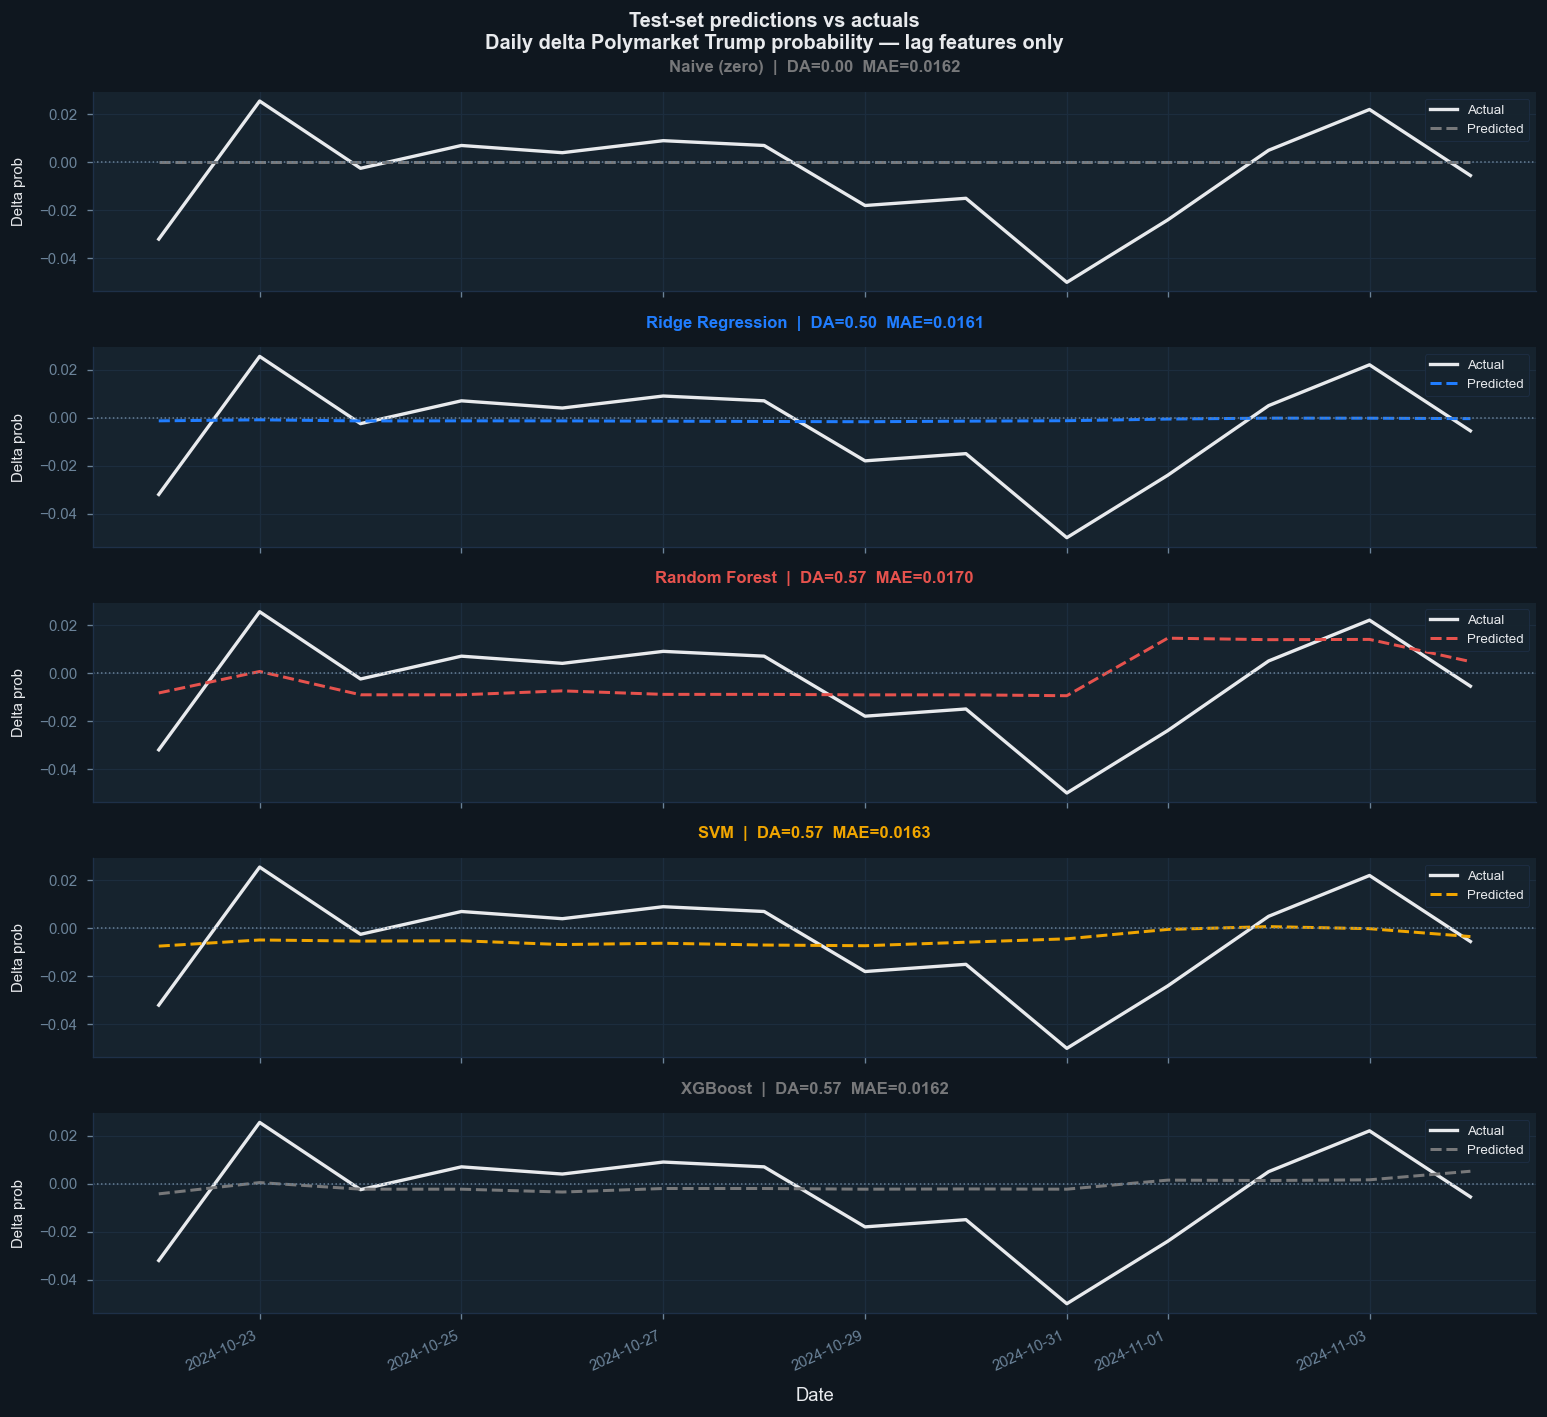

In [39]:
test_dates = df_test["date"].values
preds_list = [
    ("Naive (zero)",      naive_pred),
    ("Ridge Regression",  lr_pred),
    ("Random Forest",     rf_pred),
    ("SVM",               svm_pred),
    ("XGBoost",           xgb_pred),
]

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)
fig.patch.set_facecolor(BG_DARK)

for ax, (label, pred) in zip(axes, preds_list):
    ax.set_facecolor(BG_PANEL)
    ax.plot(test_dates, y_test, label="Actual",    color=TEXT_PRIMARY, linewidth=2)
    ax.plot(test_dates, pred,   label="Predicted", color=MODEL_COLORS[label],
            linewidth=1.8, linestyle="--")
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=":")
    da  = directional_accuracy(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(f"{label}  |  DA={da:.2f}  MAE={mae:.4f}",
                 color=MODEL_COLORS[label], fontweight="bold", fontsize=10)
    ax.set_ylabel("Delta prob", color=TEXT_PRIMARY, fontsize=9)
    ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Date", color=TEXT_PRIMARY)
plt.xticks(rotation=25, ha="right")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability — lag features only",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

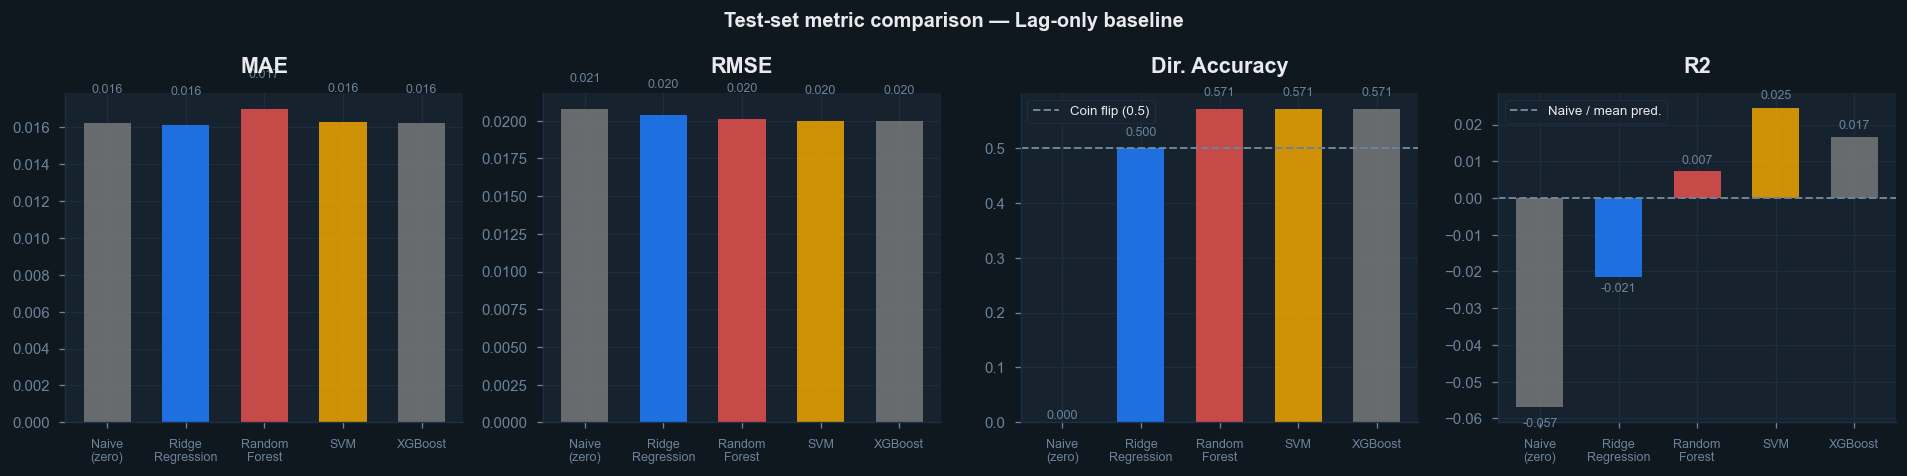

In [40]:
metrics_plot = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
model_names  = list(MODEL_COLORS.keys())
colors_list  = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor(BG_DARK)

for ax, metric in zip(axes, metrics_plot):
    ax.set_facecolor(BG_PANEL)
    vals = [test_summary.loc[m, metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=colors_list, alpha=0.85, width=0.6)

    if metric == "Dir. Accuracy":
        ax.axhline(0.5, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Coin flip (0.5)")
    if metric == "R2":
        ax.axhline(0, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Naive / mean pred.")

    for bar, val in zip(bars, vals):
        offset = abs(val) * 0.03 + 0.001
        va     = "bottom" if val >= 0 else "top"
        y_pos  = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{val:.3f}", ha="center", va=va, fontsize=7.5, color=TEXT_MUTED)

    ax.set_title(metric, color=TEXT_PRIMARY, fontweight="bold")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       fontsize=7.5, color=TEXT_MUTED)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    if metric in ("Dir. Accuracy", "R2"):
        ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

fig.suptitle("Test-set metric comparison — Lag-only baseline",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [41]:
from pathlib import Path

# ── Export test-set results to CSV for model_analysis.ipynb ──────────────────
FEATURE_SET = "Lag (2f)"
CSV_NAME    = "lag_2f.csv"
OUT_DIR     = Path("../../4_model_analysis/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_export = test_summary.copy()
df_export.index.name = "Model"
df_export = df_export.reset_index()
df_export = df_export.rename(columns={"Dir. Accuracy": "DA"})
df_export["Model"] = df_export["Model"].replace({"Ridge Regression": "Ridge"})
df_export.insert(0, "Feature_set", FEATURE_SET)

out_path = OUT_DIR / CSV_NAME
df_export.to_csv(out_path, index=False)
print(f"Results saved → {out_path}")
display(df_export)

Results saved → ..\..\4_model_analysis\results\lag_2f.csv


,Feature_set,Model,MAE,RMSE,DA,R2
0,Lag (2f),Naive (zero),0.0162,0.0208,0.0000,-0.0570
1,Lag (2f),Ridge,0.0161,0.0204,0.5000,-0.0215
2,Lag (2f),Random Forest,0.0170,0.0201,0.5714,0.0073
3,Lag (2f),SVM,0.0163,0.0200,0.5714,0.0245
4,Lag (2f),XGBoost,0.0162,0.0200,0.5714,0.0165
